# Radio Signal Parameter Estimation: Issues & Solutions Log

This notebook documents the process of training a physics-informed neural network to estimate the phase offset of a 16-QAM radio signal and reconstruct it. Below is a summary of the critical issues encountered during development and the solutions that led to a successful model (BER < 1%).

### 1. The "Symmetry Ambiguity" Problem

* **Issue:** The initial model converged to a loss of ~1.0 (random guessing) and a BER of ~0.85.
* **Root Cause:** 16-QAM is rotationally symmetric every $90^\circ$ ($\pi/2$). Without an external reference, the network cannot distinguish between true $\theta$ and $\theta+90^\circ$. It attempts to average these possibilities, leading to a destructive mean of 0.
* **Solution:** **Pilot-Aided Estimation**. We explicitly feed the first $N=4$ known symbols ("pilots") into the network. These act as a "phase anchor," breaking the symmetry and allowing the network to lock onto the correct quadrant.

### 2. The "Lazy Network" / Vanishing Gradient Problem

* **Issue:** Even with pilots, the network initially ignored them because the sparse pilot signal ($8$ floats) was drowned out by the noisy data signal ($1024$ floats).
* **Root Cause:** The network struggled to learn the specific complex-conjugate arithmetic required to extract phase from pilots from scratch (the optimization landscape was too flat).
* **Solution:** **Physics-Informed Residual Learning**. We calculate a "Classical Hint" (a rough Coarse Estimate using the pilots via Least Squares) and feed this vector $[\cos \hat{\theta}, \sin \hat{\theta}]$ into the network.
* *Result:* The NN no longer needs to learn the phase from zero; it only needs to learn the **Residual Correction** ($\Delta \theta$) to account for noise and non-linearities, which is a much easier task.



### 3. Input Normalization & SNR Curriculum

* **Issue:** Gradients were unstable, and the MLP struggled to converge on raw IQ data.
* **Solution:**
1. **Batch Normalization:** Added `BatchNorm1d` immediately after flattening inputs to center the data and keep variance unit-scale.
2. **SNR Randomization:** We trained on a dynamic SNR range ($15 - 30$ dB). This prevented the model from overfitting to clean signals and forced it to learn robust feature extraction for noisy environments.



### 4. Manifold-Aware Loss

* **Issue:** Using MSE (Mean Squared Error) on raw angles fails because $-\pi$ and $+\pi$ are far apart in Euclidean numbers but identical in physical phase (the "wrap-around" problem).
* **Solution:** We predict a vector $[\cos \theta, \sin \theta]$ and maximize the cosine similarity. The loss function is $L = 1 - \cos(\theta_{pred} - \theta_{true})$, which is differentiable and correctly respects the circular geometry of the phase manifold.

---

Using device: cuda
--- Starting Hybrid Training (20 Epochs) ---
Epoch 01 | Loss: 0.5169 | Phase MAE: 0.4546 rad | BER: 0.44245
Epoch 02 | Loss: 0.0936 | Phase MAE: 0.2094 rad | BER: 0.18057
Epoch 03 | Loss: 0.0270 | Phase MAE: 0.1305 rad | BER: 0.05536
Epoch 04 | Loss: 0.0165 | Phase MAE: 0.1142 rad | BER: 0.03846
Epoch 05 | Loss: 0.0136 | Phase MAE: 0.1065 rad | BER: 0.02724
Epoch 06 | Loss: 0.0126 | Phase MAE: 0.0961 rad | BER: 0.01989
Epoch 07 | Loss: 0.0122 | Phase MAE: 0.0937 rad | BER: 0.01673
Epoch 08 | Loss: 0.0112 | Phase MAE: 0.0885 rad | BER: 0.01473
Epoch 09 | Loss: 0.0109 | Phase MAE: 0.0861 rad | BER: 0.01199
Epoch 10 | Loss: 0.0100 | Phase MAE: 0.0838 rad | BER: 0.01058
Epoch 11 | Loss: 0.0103 | Phase MAE: 0.0798 rad | BER: 0.00956
Epoch 12 | Loss: 0.0106 | Phase MAE: 0.0808 rad | BER: 0.01118
Epoch 13 | Loss: 0.0099 | Phase MAE: 0.0799 rad | BER: 0.00889
Epoch 14 | Loss: 0.0095 | Phase MAE: 0.0734 rad | BER: 0.00770
Epoch 15 | Loss: 0.0095 | Phase MAE: 0.0743 rad | BER:

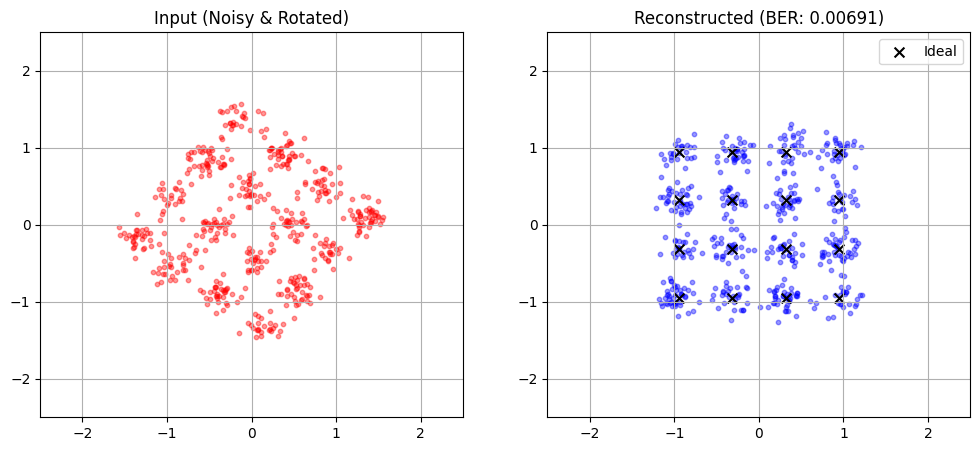

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------------------
# 1. Configuration & Hyperparameters
# -------------------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
EPOCHS = 20
LR = 0.001
SEQ_LEN = 512
N_PILOTS = 4         # Number of known symbols for phase locking
SNRS_DB = (15, 30)   # Training SNR range (dB)

print(f"Using device: {DEVICE}")

# -------------------------------------------------------------------------------------
# 2. Helpers: 16-QAM & Utilities
# -------------------------------------------------------------------------------------
def get_16qam_constellation():
    """Returns complex constellation points and bit lookup."""
    gray_map = {0: -3, 1: -1, 3: 1, 2: 3}
    const = []
    
    # Generate points normalized to unit power
    # Normalization factor 1/sqrt(10)
    norm = 1.0 / np.sqrt(10)
    
    # We want indices 0..15 to match specific bit patterns
    # Create a map first
    temp_map = {}
    for i_bits, i_val in gray_map.items():
        for q_bits, q_val in gray_map.items():
            # Combine bits: (i1 i0 q1 q0)
            combined_bits = (i_bits << 2) | q_bits
            symbol = complex(i_val, q_val) * norm
            temp_map[combined_bits] = symbol
            
    # List sorted by integer index 0..15
    sorted_const = [temp_map[i] for i in range(16)]
    return np.array(sorted_const), temp_map

CONST_POINTS, _ = get_16qam_constellation()
CONST_TENSOR = torch.tensor(CONST_POINTS, dtype=torch.complex64, device=DEVICE)

def demap_16qam(iq_tensor):
    """
    Hard Slicing / Demodulation.
    Finds the nearest constellation point index (0-15).
    """
    # Distance metric: |x - c|^2
    # Shape: (B, T, 1) - (1, 1, 16) -> (B, T, 16)
    dist = torch.abs(iq_tensor.unsqueeze(-1) - CONST_TENSOR.unsqueeze(0).unsqueeze(0))
    return torch.argmin(dist, dim=-1)

def classical_pilot_estimate(noisy_pilots, clean_pilots):
    """
    Least-Squares Phase Estimation using Pilots.
    e^(j*theta) ~ sum(rx * conj(tx))
    """
    # noisy: (B, P) complex
    # clean: (B, P) complex
    phasor = (noisy_pilots * torch.conj(clean_pilots)).sum(dim=1)
    # Normalize to unit vector (cos, sin)
    phasor = phasor / (torch.abs(phasor) + 1e-8)
    return torch.stack([phasor.real, phasor.imag], dim=1).float()

# -------------------------------------------------------------------------------------
# 3. Dataset: Synthetic 16-QAM with Rotation
# -------------------------------------------------------------------------------------
class RadioDataset(Dataset):
    def __init__(self, N=5000, seq_len=SEQ_LEN, snr_range=SNRS_DB):
        self.N = N
        self.seq_len = seq_len
        self.snr_min, self.snr_max = snr_range
        self.const = CONST_POINTS
        
    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        # 1. Generate Random Symbols (0-15)
        sym_ints = np.random.randint(0, 16, size=self.seq_len)
        clean_iq = self.const[sym_ints]
        
        # 2. Generate Random Phase Offset (-pi to pi)
        phase_true = np.random.uniform(-np.pi, np.pi)
        rotation = np.exp(1j * phase_true)
        
        # 3. Apply Channel (Rotation + AWGN)
        rotated_iq = clean_iq * rotation
        
        snr_db = np.random.uniform(self.snr_min, self.snr_max)
        snr_linear = 10**(snr_db/10)
        p_signal = np.mean(np.abs(clean_iq)**2)
        p_noise = p_signal / snr_linear
        
        # Complex Noise
        noise = (np.random.randn(self.seq_len) + 1j*np.random.randn(self.seq_len)) * np.sqrt(p_noise/2)
        noisy_iq = rotated_iq + noise
        
        # 4. Format for Pytorch
        # Signal: (2, T)
        x = np.stack([noisy_iq.real, noisy_iq.imag], axis=0).astype(np.float32)
        
        return torch.from_numpy(x), torch.tensor(phase_true).float(), torch.from_numpy(sym_ints)

# -------------------------------------------------------------------------------------
# 4. Network: Physics-Informed (Hybrid) Estimator
# -------------------------------------------------------------------------------------
class HybridPhaseNet(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, n_pilots=N_PILOTS):
        super().__init__()
        
        # Input Features:
        # 1. Flattened Noisy Signal (2 * T)
        # 2. Flattened Known Pilots (2 * P)
        # 3. Classical Hint Vector  (2) -> [cos_est, sin_est]
        input_dim = (2 * seq_len) + (2 * n_pilots) + 2
        
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(input_dim), # Normalize inputs
            
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            
            nn.Linear(128, 2) # Output residual correction vector
        )

    def forward(self, x, pilots, hint):
        # x: (B, 2, T)
        # pilots: (B, 2, P)
        # hint: (B, 2)
        
        x_flat = x.view(x.size(0), -1)
        p_flat = pilots.view(pilots.size(0), -1)
        
        # Concatenate all information
        combined = torch.cat([x_flat, p_flat, hint], dim=1)
        
        vec = self.net(combined)
        
        # Return angle
        return torch.atan2(vec[:, 1], vec[:, 0])

# -------------------------------------------------------------------------------------
# 5. Training Loop
# -------------------------------------------------------------------------------------
# Load Data
dataset = RadioDataset(N=10000)
train_size = int(0.8 * len(dataset))
train_ds, val_ds = random_split(dataset, [train_size, len(dataset)-train_size])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# Model & Optimization
model = HybridPhaseNet().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
# Loss: 1 - cos(error)
loss_fn = lambda p, t: 1.0 - torch.cos(p - t).mean()

print(f"--- Starting Hybrid Training ({EPOCHS} Epochs) ---")
history = {'loss': [], 'mae': [], 'ber': []}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for x, theta, sym_ints in train_loader:
        x, theta, sym_ints = x.to(DEVICE), theta.to(DEVICE), sym_ints.to(DEVICE)
        
        # --- PREPARE FEATURES ---
        # 1. Get Pilots (Ground Truth for first N symbols)
        pilot_idx = sym_ints[:, :N_PILOTS]
        pilot_ref_complex = CONST_TENSOR[pilot_idx] # (B, P)
        
        # 2. Get Received Pilots (Noisy)
        x_complex = torch.complex(x[:,0,:], x[:,1,:])
        pilot_rx_complex = x_complex[:, :N_PILOTS] # (B, P)
        
        # 3. Compute Classical Hint
        hint = classical_pilot_estimate(pilot_rx_complex, pilot_ref_complex)
        
        # 4. Format Pilot Tensor for NN
        pilots_feat = torch.stack([pilot_ref_complex.real, pilot_ref_complex.imag], dim=1).float()
        
        # --- OPTIMIZATION ---
        optimizer.zero_grad()
        theta_est = model(x, pilots_feat, hint)
        loss = loss_fn(theta_est, theta)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    
    # --- EVALUATION ---
    model.eval()
    val_mae = 0.0
    val_ber = 0.0
    total_syms = 0
    
    with torch.no_grad():
        for x, theta, sym_ints in val_loader:
            x, theta, sym_ints = x.to(DEVICE), theta.to(DEVICE), sym_ints.to(DEVICE)
            
            # Re-create features for validation
            pilot_idx = sym_ints[:, :N_PILOTS]
            pilot_ref_complex = CONST_TENSOR[pilot_idx]
            x_complex = torch.complex(x[:,0,:], x[:,1,:])
            pilot_rx_complex = x_complex[:, :N_PILOTS]
            hint = classical_pilot_estimate(pilot_rx_complex, pilot_ref_complex)
            pilots_feat = torch.stack([pilot_ref_complex.real, pilot_ref_complex.imag], dim=1).float()
            
            # Estimate
            theta_est = model(x, pilots_feat, hint)
            
            # 1. Phase Error
            diff = torch.atan2(torch.sin(theta_est - theta), torch.cos(theta_est - theta))
            val_mae += torch.abs(diff).sum().item()
            
            # 2. Reconstruction & BER
            correction = torch.exp(-1j * theta_est.unsqueeze(1))
            rx_corrected = x_complex * correction
            est_idx = demap_16qam(rx_corrected)
            
            # Check errors (excluding pilots if desired, but including here for simplicity)
            val_ber += (est_idx != sym_ints).sum().item()
            total_syms += sym_ints.numel()
            
    epoch_mae = val_mae / (len(val_ds) * 1) # Avg per batch is easier, but sum/N is exact
    # Correct normalization for MAE: sum(abs_diff) / N_samples
    epoch_mae = val_mae / len(val_ds) 
    epoch_ber = val_ber / total_syms
    
    history['loss'].append(avg_loss)
    history['ber'].append(epoch_ber)
    
    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Phase MAE: {epoch_mae:.4f} rad | BER: {epoch_ber:.5f}")

# --- SAVE MODEL ---
MODEL_PATH = "./models/PhaseNet_hybrid.pth"
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model successfully saved to: {MODEL_PATH}")

# -------------------------------------------------------------------------------------
# 6. Final Visualization (Corrected)
# -------------------------------------------------------------------------------------

plt.figure(figsize=(12, 5))

# Get one validation batch
x, theta, sym_ints = next(iter(val_loader))
x, theta, sym_ints = x.to(DEVICE), theta.to(DEVICE), sym_ints.to(DEVICE)

# Re-run inference
pilot_idx = sym_ints[:, :N_PILOTS]
pilot_ref = CONST_TENSOR[pilot_idx]
x_c = torch.complex(x[:,0,:], x[:,1,:])
hint = classical_pilot_estimate(x_c[:, :N_PILOTS], pilot_ref)
p_feat = torch.stack([pilot_ref.real, pilot_ref.imag], dim=1).float()
est = model(x, p_feat, hint)

# Plot
idx = 0
# FIX: Added .detach() before .cpu().numpy()
rx_raw = x_c[idx].detach().cpu().numpy()
correction = torch.exp(-1j * est[idx])
rx_clean = (x_c[idx] * correction).detach().cpu().numpy()

plt.subplot(1, 2, 1)
plt.scatter(rx_raw.real, rx_raw.imag, s=10, alpha=0.4, c='r')
plt.title("Input (Noisy & Rotated)")
plt.grid(True); plt.xlim(-2.5, 2.5); plt.ylim(-2.5, 2.5)

plt.subplot(1, 2, 2)
plt.scatter(rx_clean.real, rx_clean.imag, s=10, alpha=0.4, c='b')
ideal = CONST_POINTS # Numpy array
plt.scatter(ideal.real, ideal.imag, s=50, marker='x', c='k', label='Ideal')
plt.title(f"Reconstructed (BER: {epoch_ber:.5f})")
plt.grid(True); plt.xlim(-2.5, 2.5); plt.ylim(-2.5, 2.5)
plt.legend()

plt.show()